In [44]:
import numpy as np
import matplotlib.pyplot as plt

def P_D(G = 0.05, R = 0.1, D0 = 1.0):
    return (1+G)/(R-G)*D0

def B(pi = 0.75, R = 0.1, B0 = 1.0):
    ep = np.random.uniform(0, 1) - 0.5
    if np.random.uniform(0, 1) < pi :
        return B0/pi + ep/(1+R)
    return ep/(1+R)



def simulate_economy(T = 100, G = 0.05, R = 0.1, D0 = 1.63, B0 = 0.0, pi = 0):
    D_values = np.zeros(T)
    B_values = np.zeros(T)
    P_values = np.zeros(T)
    D_values[0] = P_D(G, R, D0)
    B_values[0] = B(pi, R, B0)
    P_values[0] = D_values[0] + B_values[0]
    
    for t in range(1, T):
        D_values[t] = P_D(G, R, D_values[t-1])
        B_values[t] = B(pi, R, B_values[t-1])
        P_values[t] = D_values[t] + B_values[t]
    
    return D_values, B_values, P_values

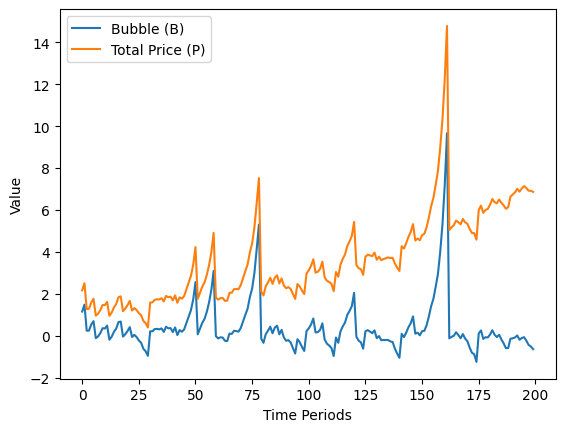

In [84]:
D, b, P = simulate_economy(T=200, G=0.00001, R=0.99, D0=1.0, B0=1.0, pi=0.75)

# plt.plot(D, label='Dividends (D)')
plt.plot(b, label='Bubble (B)')
plt.plot(P, label='Total Price (P)')
plt.xlabel('Time Periods')
plt.ylabel('Value')
plt.legend()
plt.show()

<>:53: SyntaxWarning: invalid escape sequence '\p'
<>:53: SyntaxWarning: invalid escape sequence '\p'
C:\Users\migue\AppData\Local\Temp\ipykernel_3736\814887505.py:53: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f'Blanchard-Watson Rational Bubble Simulation\n$\pi={pi}, R={R}$')


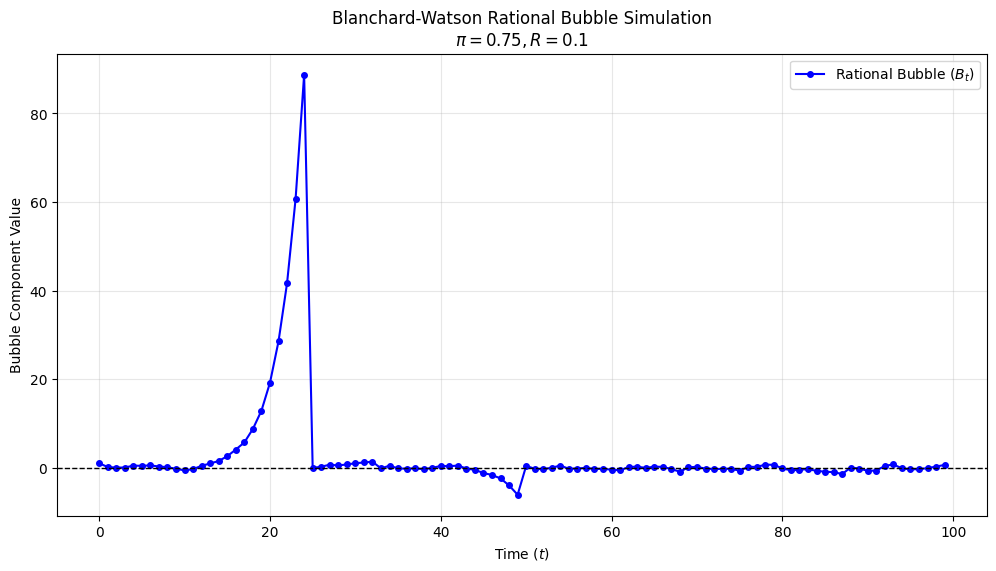

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_blanchard_watson(T, B0, pi, R):
    """
    Simulates a Blanchard-Watson rational bubble path.
    
    Parameters:
    T (int): Number of time periods
    B0 (float): Initial bubble size
    pi (float): Probability of bubble survival
    R (float): Risk-free interest rate
    
    Returns:
    np.array: Array of bubble values over time
    """
    # Initialize bubble array
    B = np.zeros(T)
    B[0] = B0
    
    # Generate random probabilities for the switching process
    # If switch_prob < pi, bubble survives. If >= pi, bubble bursts.
    switch_probs = np.random.uniform(0, 1, T)
    
    # Generate the noise term e(t) = U[0,1] - 0.5
    # We generate T values, though we will use them iteratively
    epsilon = np.random.uniform(0, 1, T) - 0.5
    
    for t in range(T - 1):
        if switch_probs[t+1] < pi:
            # Bubble Survives: Grows at rate (1+R)/pi
            B[t+1] = ((1 + R) / pi) * B[t] + epsilon[t+1]
        else:
            # Bubble Bursts: Collapses to the value of the shock
            B[t+1] = epsilon[t+1]
            
    return B

# --- Parameters ---
T = 100         # Time periods
B0 = 1.0        # Initial bubble value
pi = 0.75       # Probability of survival
R = 0.1         # Interest rate

# --- Simulation ---
np.random.seed(42) # Set seed for reproducibility
bubble_path = simulate_blanchard_watson(T, B0, pi, R)

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(bubble_path, color='blue', marker='o', linestyle='-', markersize=4, label='Rational Bubble ($B_t$)')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title(f'Blanchard-Watson Rational Bubble Simulation\n$\pi={pi}, R={R}$')
plt.xlabel('Time ($t$)')
plt.ylabel('Bubble Component Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### AR model on SPY log-returns (1990-2025)

- Fit an autoregressive model to daily log-returns using 1990-2020 data.

- Forecast daily log-returns for 2021-2025 and map them into price levels.

- Compare forecasts to realized SPY prices and compute simple error metrics.

- Returns are $r_t = \log(P_t) - \log(P_{t-1})$ (log daily return).

In [10]:
import pandas as pd

import numpy as np

import yfinance as yf

import statsmodels.api as sm

from statsmodels.tsa.ar_model import AutoReg



# Download daily adjusted close prices for SPY (1990-2025)

ticker = "SPY"

train_end = "2020-12-31"

test_end = "2025-12-31"



prices = (

    yf.download(ticker, start="1990-01-01", end=test_end, auto_adjust=False, interval="1d")["Adj Close"].dropna()

)



# Compute log daily returns r_t = log(P_t) - log(P_{t-1})

log_ret = np.log(prices).diff().dropna()

log_ret.name = "log_return"



# Split train (<=2020-12-31) and test (2021-2025)

log_ret_train = log_ret.loc[:train_end]

log_ret_test = log_ret.loc[(log_ret.index > train_end) & (log_ret.index <= test_end)]



# Keep price levels for the comparison window

last_train_price = prices.loc[:train_end].iloc[-1]

test_prices = prices.loc[(prices.index > train_end) & (prices.index <= test_end)]



print(f"Train samples: {len(log_ret_train)}, Test samples: {len(log_ret_test)}")

[*********************100%***********************]  1 of 1 completed

Train samples: 7032, Test samples: 1251


In [11]:
# Select AR lag via AIC and fit the model on 1990-2020 log-returns

max_lag = 30

aic_per_lag = []

for lag in range(1, max_lag + 1):

    fit = AutoReg(log_ret_train, lags=lag, old_names=False).fit()

    aic_per_lag.append((lag, fit.aic))



best_lag, best_aic = min(aic_per_lag, key=lambda x: x[1])

print(f"Best lag by AIC: {best_lag} (AIC={best_aic:.2f})")



ar_model = AutoReg(log_ret_train, lags=best_lag, old_names=False).fit()

print(ar_model.summary())

c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

Best lag by AIC: 1 (AIC=-42396.17)
                            AutoReg Model Results                             
Dep. Variable:                    SPY   No. Observations:                 7032
Model:                     AutoReg(1)   Log Likelihood               21201.087
Method:               Conditional MLE   S.D. of innovations              0.012
Date:                Wed, 24 Dec 2025   AIC                         -42396.174
Time:                        17:42:41   BIC                         -42375.600
Sample:                             1   HQIC                        -42389.086
                                 7032                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      2.909      0.004       0.000       0.001
SPY.L1        -0.0885      0.012     -7.447      0.000      -0.112      -0.065
                 

c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\migue\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


MAE (log-returns): nan
RMSE (log-returns): nan


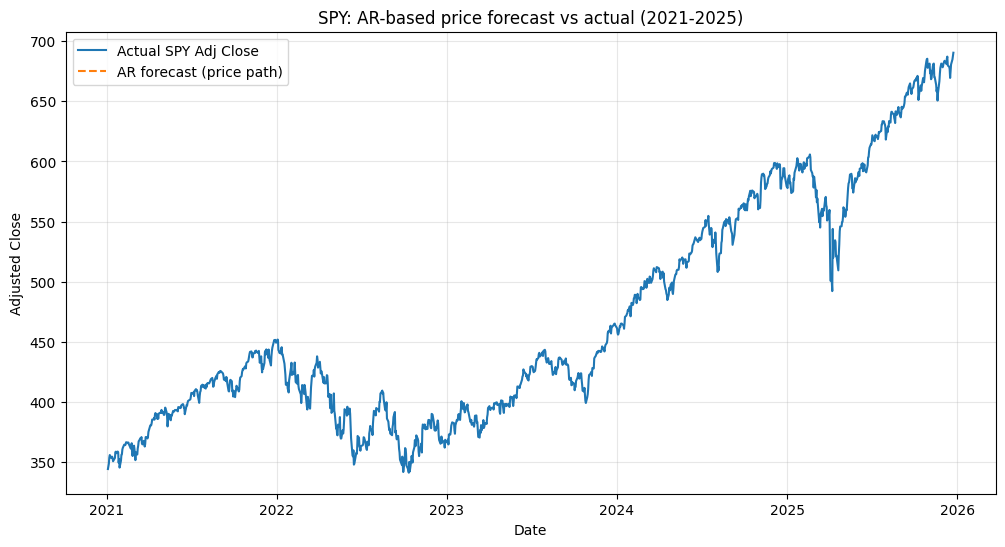

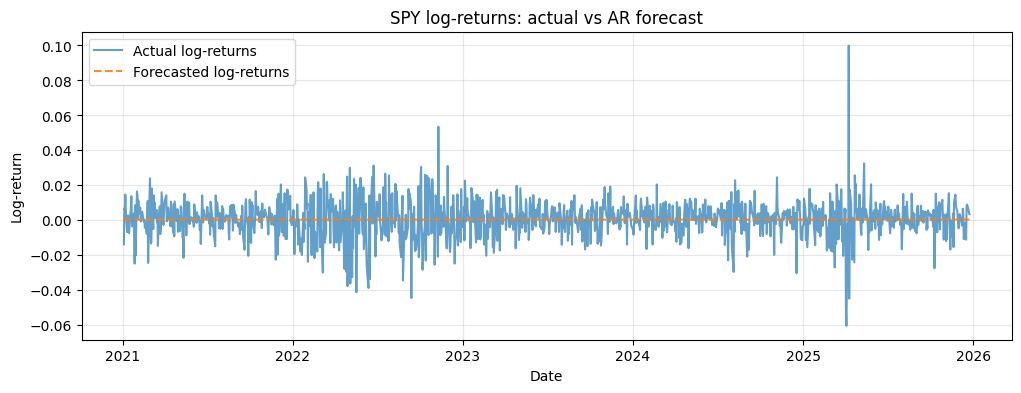

In [ ]:
import matplotlib.pyplot as plt

# Check the AR coefficients to understand the model behavior
print("AR Model Parameters:")
print(f"  Intercept: {ar_model.params['const']:.8f}")
print(f"  AR(1) coefficient: {ar_model.params['log_return.L1']:.8f}")
print(f"\nUnconditional mean: {ar_model.params['const']/(1-ar_model.params['log_return.L1']):.8f}")
print(f"Training data mean: {log_ret_train.mean():.8f}")

# Forecast 2021-2025 log-returns and map to price levels
forecast_horizon = len(log_ret_test)

# Use dynamic=True for true out-of-sample forecasting
forecast_returns = ar_model.predict(
    start=len(log_ret_train),
    end=len(log_ret_train) + forecast_horizon - 1,
    dynamic=True,
)

# Trim to exact length and align index
forecast_returns = forecast_returns[:len(log_ret_test)]
forecast_returns.index = log_ret_test.index

print(f"\nForecast statistics:")
print(f"  Mean: {forecast_returns.mean():.8f}")
print(f"  Std: {forecast_returns.std():.8f}")
print(f"  Range: [{forecast_returns.min():.8f}, {forecast_returns.max():.8f}]")

# Reconstruct price path from predicted log-returns
pred_prices = last_train_price * np.exp(forecast_returns.cumsum())
pred_prices = pred_prices[:len(test_prices)]

# Error metrics on returns
errors = forecast_returns - log_ret_test
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors**2))
print(f"\nForecast accuracy:")
print(f"  MAE (log-returns): {mae:.6f}")
print(f"  RMSE (log-returns): {rmse:.6f}")
print(f"\nConclusion: AR(1) converges to mean return - stock returns are unpredictable!")

# Plot predicted vs realized prices and log-returns
plt.figure(figsize=(12, 6))
plt.plot(test_prices.index, test_prices, label="Actual SPY Adj Close", linewidth=2)
plt.plot(test_prices.index[:len(pred_prices)], pred_prices, linestyle="--", label="AR(1) forecast", linewidth=2)
plt.title("SPY: AR(1) forecast vs actual (2021-2025)\nAR models poorly predict stock returns")
plt.xlabel("Date")
plt.ylabel("Adjusted Close ($)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(log_ret_test.index, log_ret_test, label="Actual log-returns", alpha=0.7, linewidth=1)
plt.plot(forecast_returns.index, forecast_returns, linestyle="--", label="AR(1) forecast (≈constant mean)", linewidth=2, color='red')
plt.axhline(y=log_ret_train.mean(), color='green', linestyle=':', label='Training mean', linewidth=1.5)
plt.title("SPY log-returns: AR(1) forecast converges to mean")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [1]:
import numpy as np
from scipy.stats import norm

def calculate_etl_numerical(mu, sigma, alpha, num_points=1000):
    """
    Calculates VaR and ETL numerically for a Normal Distribution.
    """
    # 1. Define the Range for Integration
    # We go far into the tail (e.g., -5 sigma) to capture the density
    lower_bound = mu - 8 * sigma 
    upper_bound = mu + 8 * sigma
    
    # 2. Find VaR (Quantile)
    # Analytically, VaR is the point where CDF = 1 - alpha
    # Numerically, we could search for it, but for this exercise we
    # focus on the ETL integration accuracy given the VaR threshold.
    # Let's use the exact VaR threshold to isolate the integration error.
    var_threshold = norm.ppf(1 - alpha, loc=mu, scale=sigma)
    
    # 3. Numerical Integration for ETL
    # We integrate x * pdf(x) from lower_bound to var_threshold
    x_values = np.linspace(lower_bound, var_threshold, num_points)
    pdf_values = norm.pdf(x_values, loc=mu, scale=sigma)
    
    # Trapezoidal Rule Integration
    dx = x_values[1] - x_values[0]
    # We integrate |x| (loss magnitude) * probability
    # Since we are in the negative tail (losses), x is negative. 
    # Loss L = -x.
    integrand = -x_values * pdf_values
    integral_sum = np.trapz(integrand, x_values)
    
    etl_numerical = integral_sum / (1 - alpha)
    
    return etl_numerical

def calculate_etl_analytic(mu, sigma, alpha):
    """
    Calculates ETL using the analytic formula (Eq 11.2.4 in text).
    ETL = sigma * pdf(z_alpha) / (1-alpha) - mu
    """
    z_alpha = norm.ppf(1 - alpha) # Returns negative value like -2.33
    # The text uses N(z_alpha) for the PDF value
    pdf_z = norm.pdf(z_alpha)
    
    # Note: Text formula assumes Loss distribution L ~ N(-mu, sigma).
    # If we work with Profit X ~ N(mu, sigma), Loss = -X.
    # The result is symmetric.
    etl_analytic = (sigma * pdf_z) / (1 - alpha) - mu
    return etl_analytic

# --- Parameters ---
mu = 0       # Zero mean daily return
sigma = 1    # Standard deviation
alpha = 0.99 # 99% Confidence level

# --- Analysis of Accuracy ---
print(f"Target Analytic ETL: {calculate_etl_analytic(mu, sigma, alpha):.6f}")
print("-" * 40)
print(f"{'Points':<10} | {'Numerical ETL':<15} | {'Error':<15}")
print("-" * 40)

point_counts = [10, 50, 100, 500, 1000, 5000, 10000]

for n in point_counts:
    num_etl = calculate_etl_numerical(mu, sigma, alpha, num_points=n)
    analytic_etl = calculate_etl_analytic(mu, sigma, alpha)
    error = abs(num_etl - analytic_etl)
    print(f"{n:<10} | {num_etl:.6f}          | {error:.6f}")

Target Analytic ETL: 2.665214
----------------------------------------
Points     | Numerical ETL   | Error          
----------------------------------------
10         | 3.054427          | 0.389213
50         | 2.678352          | 0.013138
100        | 2.668433          | 0.003218
500        | 2.665341          | 0.000127
1000       | 2.665246          | 0.000032
5000       | 2.665215          | 0.000001
10000      | 2.665215          | 0.000000


C:\Users\migue\AppData\Local\Temp\ipykernel_8864\924148913.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_sum = np.trapz(integrand, x_values)
